ORIGINAL AIRLINE DATA


,airline,destination,on_time,delayed
0,ALASKA,Los Angeles,497,62
1,ALASKA,Phoenix,221,12
2,ALASKA,San Diego,212,20
3,ALASKA,San Francisco,503,102
4,ALASKA,Seattle,1841,305
5,AM WEST,Los Angeles,694,117
6,AM WEST,Phoenix,4840,415
7,AM WEST,San Diego,383,65
8,AM WEST,San Francisco,320,129
9,AM WEST,Seattle,201,61



FLIGHT TOTALS AND PERCENTAGES BY DESTINATION


,airline,destination,on_time,delayed,total_flights,delay_pct,on_time_pct
0,ALASKA,Los Angeles,497,62,559,11.09,88.91
1,ALASKA,Phoenix,221,12,233,5.15,94.85
2,ALASKA,San Diego,212,20,232,8.62,91.38
3,ALASKA,San Francisco,503,102,605,16.86,83.14
4,ALASKA,Seattle,1841,305,2146,14.21,85.79
5,AM WEST,Los Angeles,694,117,811,14.43,85.57
6,AM WEST,Phoenix,4840,415,5255,7.90,92.10
7,AM WEST,San Diego,383,65,448,14.51,85.49
8,AM WEST,San Francisco,320,129,449,28.73,71.27
9,AM WEST,Seattle,201,61,262,23.28,76.72



OVERALL AIRLINE COMPARISON


,on_time,delayed,total_flights,delay_pct,on_time_pct
airline,,,,,
ALASKA,3274,501,3775,13.27,86.73
AM WEST,6438,787,7225,10.89,89.11



DELAY PERCENTAGES BY DESTINATION


airline,ALASKA,AM WEST,AM WEST minus ALASKA (percentage points)
destination,,,
Los Angeles,11.09,14.43,3.34
Phoenix,5.15,7.90,2.75
San Diego,8.62,14.51,5.89
San Francisco,16.86,28.73,11.87
Seattle,14.21,23.28,9.07


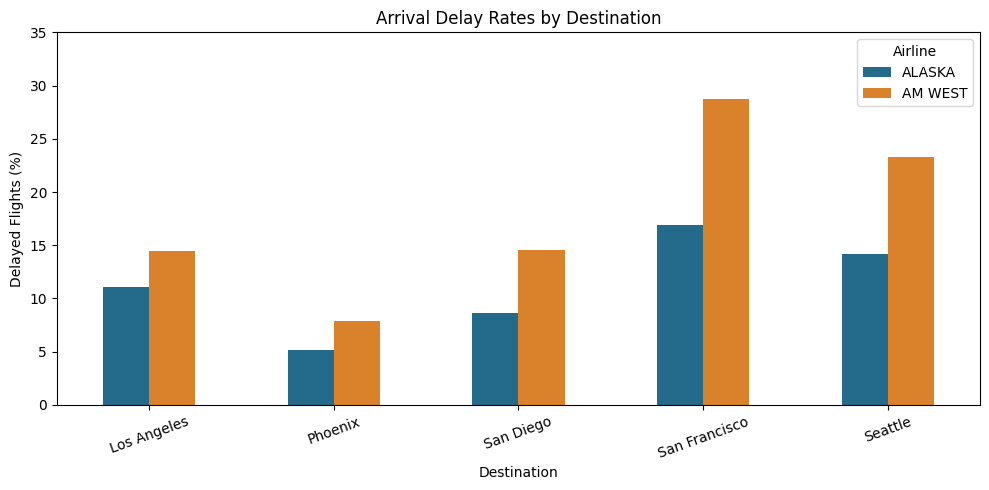


PERCENTAGE OF EACH AIRLINE'S FLIGHTS BY DESTINATION


airline,ALASKA,AM WEST
destination,,
Los Angeles,14.81,11.22
Phoenix,6.17,72.73
San Diego,6.15,6.20
San Francisco,16.03,6.21
Seattle,56.85,3.63



ANALYSIS AND CONCLUSION

ALASKA has an overall delay rate of 13.27%, while AM WEST has an overall delay rate of 10.89%.

AM WEST has the lower overall delay rate. However, ALASKA has the lower delay rate at every individual destination.

Approximately 72.73% of AM WEST's flights go to Phoenix, where both airlines have relatively low delay rates.

Approximately 56.85% of ALASKA's flights go to Seattle, where both airlines have higher delay rates than in Phoenix.

This reversal between the destination-specific results and the overall results is an example of Simpson's paradox. The airlines' different distributions of flights across destinations explain the reversal.

When comparing the airlines at the same destination, the destination-specific delay rates are more informative. The overall rates describe each airline's actual mix of flights in this dataset.

The data does not identify the time period, causes of delays, or delay lengths. These results describe this dataset and do not esta

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

csv_data = """airline,destination,on_time,delayed
ALASKA,Los Angeles,497,62
ALASKA,Phoenix,221,12
ALASKA,San Diego,212,20
ALASKA,San Francisco,503,102
ALASKA,Seattle,1841,305
AM WEST,Los Angeles,694,117
AM WEST,Phoenix,4840,415
AM WEST,San Diego,383,65
AM WEST,San Francisco,320,129
AM WEST,Seattle,201,61
"""

Path("airline_delays.csv").write_text(csv_data, encoding="utf-8")

df = pd.read_csv("airline_delays.csv")

print("ORIGINAL AIRLINE DATA")
display(df)

df["total_flights"] = df["on_time"] + df["delayed"]
df["delay_pct"] = df["delayed"] / df["total_flights"] * 100
df["on_time_pct"] = df["on_time"] / df["total_flights"] * 100

print("\nFLIGHT TOTALS AND PERCENTAGES BY DESTINATION")
display(df.round(2))

overall = df.groupby("airline")[
    ["on_time", "delayed", "total_flights"]
].sum()

overall["delay_pct"] = (
    overall["delayed"] / overall["total_flights"] * 100
)

overall["on_time_pct"] = (
    overall["on_time"] / overall["total_flights"] * 100
)

print("\nOVERALL AIRLINE COMPARISON")
display(overall.round(2))

by_destination = df.pivot(
    index="destination",
    columns="airline",
    values="delay_pct"
)

comparison = by_destination.copy()

comparison["AM WEST minus ALASKA (percentage points)"] = (
    comparison["AM WEST"] - comparison["ALASKA"]
)

print("\nDELAY PERCENTAGES BY DESTINATION")
display(comparison.round(2))

ax = by_destination.plot(
    kind="bar",
    figsize=(10, 5),
    color=["#246A8A", "#D9822B"]
)

ax.set_title("Arrival Delay Rates by Destination")
ax.set_xlabel("Destination")
ax.set_ylabel("Delayed Flights (%)")
ax.set_ylim(0, 35)
ax.tick_params(axis="x", labelrotation=20)
ax.legend(title="Airline")

plt.tight_layout()
plt.show()

df["flight_share_pct"] = (
    df["total_flights"]
    / df.groupby("airline")["total_flights"].transform("sum")
    * 100
)

flight_shares = df.pivot(
    index="destination",
    columns="airline",
    values="flight_share_pct"
)

print("\nPERCENTAGE OF EACH AIRLINE'S FLIGHTS BY DESTINATION")
display(flight_shares.round(2))

alaska_rate = overall.loc["ALASKA", "delay_pct"]
am_west_rate = overall.loc["AM WEST", "delay_pct"]

alaska_seattle_share = flight_shares.loc["Seattle", "ALASKA"]
am_west_phoenix_share = flight_shares.loc["Phoenix", "AM WEST"]

print("\nANALYSIS AND CONCLUSION")

print(
    f"\nALASKA has an overall delay rate of {alaska_rate:.2f}%, "
    f"while AM WEST has an overall delay rate of {am_west_rate:.2f}%."
)

print(
    "\nAM WEST has the lower overall delay rate. However, ALASKA "
    "has the lower delay rate at every individual destination."
)

print(
    f"\nApproximately {am_west_phoenix_share:.2f}% of AM WEST's "
    "flights go to Phoenix, where both airlines have relatively "
    "low delay rates."
)

print(
    f"\nApproximately {alaska_seattle_share:.2f}% of ALASKA's "
    "flights go to Seattle, where both airlines have higher "
    "delay rates than in Phoenix."
)

print(
    "\nThis reversal between the destination-specific results "
    "and the overall results is an example of Simpson's paradox. "
    "The airlines' different distributions of flights across "
    "destinations explain the reversal."
)

print(
    "\nWhen comparing the airlines at the same destination, "
    "the destination-specific delay rates are more informative. "
    "The overall rates describe each airline's actual mix "
    "of flights in this dataset."
)

print(
    "\nThe data does not identify the time period, causes of "
    "delays, or delay lengths. These results describe this "
    "dataset and do not establish what caused the delays "
    "or predict future performance."
)